# Fashion MNIST

Epoch 1: Train Acc = 0.814, Val Acc = 0.851
Epoch 2: Train Acc = 0.862, Val Acc = 0.863
Epoch 3: Train Acc = 0.877, Val Acc = 0.868
Epoch 4: Train Acc = 0.885, Val Acc = 0.878
Epoch 5: Train Acc = 0.892, Val Acc = 0.873
Epoch 6: Train Acc = 0.895, Val Acc = 0.884
Epoch 7: Train Acc = 0.901, Val Acc = 0.874
Epoch 8: Train Acc = 0.906, Val Acc = 0.881
Epoch 9: Train Acc = 0.909, Val Acc = 0.889
Epoch 10: Train Acc = 0.912, Val Acc = 0.885


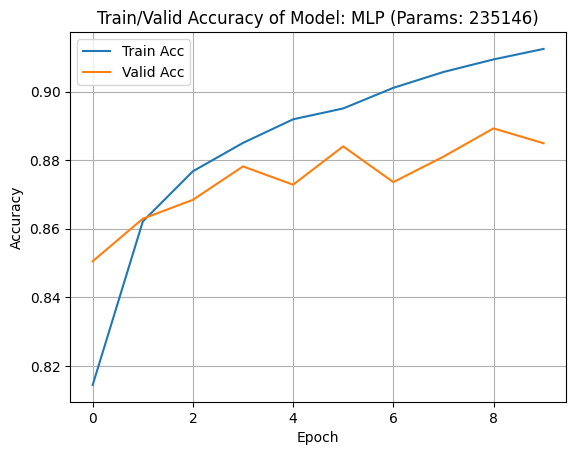

Test Accuracy: 0.881
              precision    recall  f1-score   support

           0       0.84      0.80      0.82      1000
           1       0.99      0.96      0.98      1000
           2       0.85      0.73      0.79      1000
           3       0.87      0.90      0.88      1000
           4       0.74      0.86      0.79      1000
           5       0.97      0.95      0.96      1000
           6       0.71      0.70      0.70      1000
           7       0.95      0.96      0.95      1000
           8       0.95      0.98      0.97      1000
           9       0.96      0.96      0.96      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



In [1]:
# (1) Data Loading and Preprocessing
import torch
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader

trainval_dataset = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transforms.ToTensor())
test_dataset = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transforms.ToTensor())

train_size = int(0.8 * len(trainval_dataset))
val_size = len(trainval_dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(trainval_dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=64)

# (2) Model Definition
import torch.nn as nn

# MLP
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Flatten(),              # 1x28x28 -> 784
            nn.Linear(784, 256),       # 784 -> 256
            nn.ReLU(),
            nn.Linear(256, 128),       # 256 -> 128
            nn.ReLU(),
            nn.Linear(128, 10)         # 128 -> 10
        )

    def forward(self, x):
        return self.model(x)

# LeNet architecture
class LeNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 6, kernel_size=5),  # 1x28x28 -> 6x24x24
            nn.ReLU(),
            nn.MaxPool2d(2, 2),              # 6x24x24 -> 6x12x12
            nn.Conv2d(6, 16, kernel_size=5), # 6x12x12 -> 16x8x8
            nn.ReLU(),
            nn.MaxPool2d(2, 2)               # 16x8x8 -> 16x4x4
        )
        self.fc = nn.Sequential(
            nn.Flatten(),               # 16x4x4 -> 256
            nn.Linear(16 * 4 * 4, 120), # 256 -> 120
            nn.ReLU(),
            nn.Linear(120, 84),         # 120 -> 84
            nn.ReLU(),
            nn.Linear(84, 10)           # 84 -> 10
        )

    def forward(self, x):
        x = self.conv(x)
        x = self.fc(x)
        return x

# Optional to use: VGG-like architecture
class VGG(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=3, padding=1),  # 1x28x28 -> 64x28x28
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1), # 64x28x28 -> 64x28x28
            nn.ReLU(),
            nn.MaxPool2d(2, 2),                          # 64x28x28 -> 64x14x14

            nn.Conv2d(64, 128, kernel_size=3, padding=1),  # 64x14x14 -> 128x14x14
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1), # 128x14x14 -> 128x14x14
            nn.ReLU(),
            nn.MaxPool2d(2, 2),                            # 128x14x14 -> 128x7x7

            nn.Conv2d(128, 256, kernel_size=3, padding=1), # 128x7x7 -> 256x7x7
            nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=3, padding=1), # 256x7x7 -> 256x7x7
            nn.ReLU(),
            nn.MaxPool2d(2, 2),                            # 256x7x7 -> 256x3x3

            nn.Flatten(),                   # 256x3x3 -> 2304
            nn.Linear(256 * 3 * 3, 1024),   # 2304 -> 1024
            nn.ReLU(),
            nn.Linear(1024, 10)             # 1024 -> 10
        )

    def forward(self, x):
        return self.model(x)

# Optional to use: NiN (Network in Network) architecture
class NiN(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=5, stride=1, padding=2), # 1x28x28 -> 32x28x28
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=1), # 32x28x28 -> 32x28x28
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=1), # 32x28x28 -> 32x28x28
            nn.ReLU(),
            nn.MaxPool2d(2, 2),               # 32x28x28 -> 32x14x14

            nn.Conv2d(32, 64, kernel_size=5, stride=1, padding=2), # 32x14x14 -> 64x14x14
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=1), # 64x14x14 -> 64x14x14
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=1), # 64x14x14 -> 64x14x14
            nn.ReLU(),
            nn.MaxPool2d(2, 2),               # 64x14x14 -> 64x7x7

            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1), # 64x7x7 -> 128x7x7
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=1), # 128x7x7 -> 128x7x7
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=1), # 128x7x7 -> 128x7x7
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1)),       # 128x7x7 -> 128x1x1

            nn.Flatten(),              # 128x1x1 -> 128
            nn.Linear(128, 10)         # 128 -> 10
        )

    def forward(self, x):
        return self.model(x)

# (3) Training function
import torch.optim as optim

def train(train_loader, val_loader, model, device):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    train_accs, val_accs = [], []

    best_acc = 0.0
    best_state = None

    for epoch in range(10):
        model.train()
        total_loss, correct, total = 0.0, 0, 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * x.size(0)
            correct += (out.argmax(1) == y).sum().item()
            total += y.size(0)
        train_accs.append(correct / total)

        model.eval()
        total_loss, correct, total = 0.0, 0, 0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                out = model(x)
                loss = criterion(out, y)
                total_loss += loss.item() * x.size(0)
                correct += (out.argmax(1) == y).sum().item()
                total += y.size(0)
        val_acc = correct / total
        if val_acc > best_acc:
            best_acc = val_acc
            best_state = model.state_dict()
        val_accs.append(correct / total)

        print(f"Epoch {epoch+1}: Train Acc = {train_accs[-1]:.3f}, Val Acc = {val_accs[-1]:.3f}")
    return train_accs, val_accs, best_state

# (4) Run training and plot the train/validation accuracy
import matplotlib.pyplot as plt
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = MLP().to(device)
train_accs, test_accs, best_state = train(train_loader, val_loader, model, device)
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
plt.plot(train_accs, label='Train Acc')
plt.plot(test_accs, label='Valid Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title(f"Train/Valid Accuracy of Model: {model.__class__.__name__} (Params: {num_params})")
plt.legend()
plt.grid(True)
plt.show()

# (5) Evaluate on test set
model.load_state_dict(best_state)
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)
        out = model(x)
        all_preds.append(out.argmax(1).cpu())
        all_labels.append(y.cpu())
all_preds = torch.cat(all_preds)
all_labels = torch.cat(all_labels)
print(f"Test Accuracy: {torch.sum(all_preds == all_labels).item() / len(all_labels):.3f}")

from sklearn.metrics import classification_report
print(classification_report(all_labels.numpy(), all_preds.numpy()))

# CIFAR-10

Epoch 1: Train Acc = 0.407, Val Acc = 0.434
Epoch 2: Train Acc = 0.481, Val Acc = 0.463
Epoch 3: Train Acc = 0.520, Val Acc = 0.479
Epoch 4: Train Acc = 0.547, Val Acc = 0.493
Epoch 5: Train Acc = 0.570, Val Acc = 0.497
Epoch 6: Train Acc = 0.592, Val Acc = 0.507
Epoch 7: Train Acc = 0.616, Val Acc = 0.504
Epoch 8: Train Acc = 0.637, Val Acc = 0.507
Epoch 9: Train Acc = 0.657, Val Acc = 0.505
Epoch 10: Train Acc = 0.676, Val Acc = 0.497


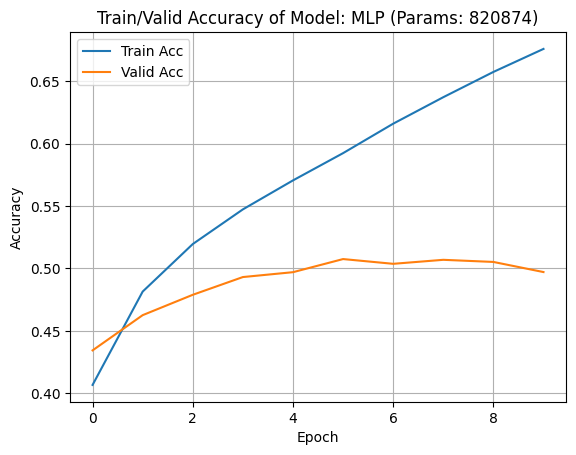

Test Accuracy: 0.510
              precision    recall  f1-score   support

           0       0.55      0.61      0.58      1000
           1       0.64      0.53      0.58      1000
           2       0.35      0.47      0.40      1000
           3       0.35      0.38      0.37      1000
           4       0.46      0.37      0.41      1000
           5       0.45      0.37      0.41      1000
           6       0.55      0.57      0.56      1000
           7       0.57      0.62      0.59      1000
           8       0.65      0.62      0.64      1000
           9       0.59      0.56      0.57      1000

    accuracy                           0.51     10000
   macro avg       0.52      0.51      0.51     10000
weighted avg       0.52      0.51      0.51     10000



In [2]:
# (1) Data Loading and Preprocessing
import torch
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# The CIFAR-10 dataset
trainval_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

train_size = int(0.8 * len(trainval_dataset))
val_size = len(trainval_dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(trainval_dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=64)

# (2) Model Definition
import torch.nn as nn

# MLP
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Flatten(),              # 3x32x32 -> 3072
            nn.Linear(3072, 256),       # 3072 -> 256
            nn.ReLU(),
            nn.Linear(256, 128),       # 256 -> 128
            nn.ReLU(),
            nn.Linear(128, 10)         # 128 -> 10
        )

    def forward(self, x):
        return self.model(x)

# LeNet architecture
class LeNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 6, kernel_size=5),  # 3x32x32 -> 6x28x28
            nn.ReLU(),
            nn.MaxPool2d(2, 2),              # 6x28x28 -> 6x14x14
            nn.Conv2d(6, 16, kernel_size=5), # 6x14x14 -> 16x10x10
            nn.ReLU(),
            nn.MaxPool2d(2, 2)               # 16x10x10 -> 16x5x5
        )
        self.fc = nn.Sequential(
            nn.Flatten(),               # 16x5x5 -> 400
            nn.Linear(16 * 5 * 5, 120), # 400 -> 120
            nn.ReLU(),
            nn.Linear(120, 84),         # 120 -> 84
            nn.ReLU(),
            nn.Linear(84, 10)           # 84 -> 10
        )

    def forward(self, x):
        x = self.conv(x)
        x = self.fc(x)
        return x

# Optional to use: VGG-like architecture
class VGG(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1),  # 3x32x32 -> 64x32x32
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1), # 64x32x32 -> 64x32x32
            nn.ReLU(),
            nn.MaxPool2d(2, 2),                          # 64x32x32 -> 64x16x16

            nn.Conv2d(64, 128, kernel_size=3, padding=1),  # 64x16x16 -> 128x16x16
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1), # 128x16x16 -> 128x16x16
            nn.ReLU(),
            nn.MaxPool2d(2, 2),                            # 128x16x16 -> 128x8x8

            nn.Conv2d(128, 256, kernel_size=3, padding=1), # 128x8x8 -> 256x8x8
            nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=3, padding=1), # 256x8x8 -> 256x8x8
            nn.ReLU(),
            nn.MaxPool2d(2, 2),                            # 256x8x8 -> 256x4x4

            nn.Flatten(),                   # 256x4x4 -> 4096
            nn.Linear(256 * 4 * 4, 1024),   # 4096 -> 1024
            nn.ReLU(),
            nn.Linear(1024, 1024),         # 1024 -> 1024
            nn.ReLU(),
            nn.Linear(1024, 10)           # 1024 -> 10
        )

    def forward(self, x):
        return self.model(x)

# Optional to use: NiN (Network in Network) architecture
class NiN(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=5, stride=1, padding=2), # 3x32x32 -> 32x32x32
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=1), # 32x32x32 -> 32x32x32
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=1), # 32x32x32 -> 32x32x32
            nn.ReLU(),
            nn.MaxPool2d(2, 2),               # 32x32x32 -> 32x16x16

            nn.Conv2d(32, 64, kernel_size=5, stride=1, padding=2), # 32x16x16 -> 64x16x16
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=1), # 64x16x16 -> 64x16x16
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=1), # 64x16x16 -> 64x16x16
            nn.ReLU(),
            nn.MaxPool2d(2, 2),               # 64x16x16 -> 64x8x8

            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1), # 64x8x8 -> 128x8x8
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=1), # 128x8x8 -> 128x8x8
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=1), # 128x8x8 -> 128x8x8
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1)),       # 128x8x8 -> 128x1x1

            nn.Flatten(),              # 128x1x1 -> 128
            nn.Linear(128, 10)         # 128 -> 10
        )

    def forward(self, x):
        return self.model(x)

# (3) Training function
import torch.optim as optim

def train(train_loader, val_loader, model, device):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    train_accs, val_accs = [], []

    best_acc = 0.0
    best_state = None

    for epoch in range(10):
        model.train()
        total_loss, correct, total = 0.0, 0, 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * x.size(0)
            correct += (out.argmax(1) == y).sum().item()
            total += y.size(0)
        train_accs.append(correct / total)

        model.eval()
        total_loss, correct, total = 0.0, 0, 0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                out = model(x)
                loss = criterion(out, y)
                total_loss += loss.item() * x.size(0)
                correct += (out.argmax(1) == y).sum().item()
                total += y.size(0)
        val_acc = correct / total
        if val_acc > best_acc:
            best_acc = val_acc
            best_state = model.state_dict()
        val_accs.append(correct / total)

        print(f"Epoch {epoch+1}: Train Acc = {train_accs[-1]:.3f}, Val Acc = {val_accs[-1]:.3f}")
    return train_accs, val_accs, best_state

# (4) Run training and plot the train/validation accuracy
import matplotlib.pyplot as plt
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = MLP().to(device)
train_accs, test_accs, best_state = train(train_loader, val_loader, model, device)
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
plt.plot(train_accs, label='Train Acc')
plt.plot(test_accs, label='Valid Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title(f"Train/Valid Accuracy of Model: {model.__class__.__name__} (Params: {num_params})")
plt.legend()
plt.grid(True)
plt.show()

# (5) Evaluate on test set
model.load_state_dict(best_state)
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)
        out = model(x)
        all_preds.append(out.argmax(1).cpu())
        all_labels.append(y.cpu())
all_preds = torch.cat(all_preds)
all_labels = torch.cat(all_labels)
print(f"Test Accuracy: {torch.sum(all_preds == all_labels).item() / len(all_labels):.3f}")

from sklearn.metrics import classification_report
print(classification_report(all_labels.numpy(), all_preds.numpy()))